In [ ]:
#rut: 21.684.318-5
#nombre: Juan Carlos Concha Hernandez
#Fecha : 27-05-2026

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar

df = pd.read_csv("dataset_produccion_s13.csv")

In [2]:
df.head(5)

,id_lote,producto,turno,unidades_producidas,costo_unitario,temperatura_horno,tiempo_ciclo_min,defectos,costo_total
0,L001,Abrazadera D,Tarde,114,1.95,204.4,37.8,8.0,222.30
1,L002,Válvula E,Tarde,306,2.83,230.8,56.8,11.0,865.98
2,L003,Tuerca C,Tarde,180,3.66,242.8,44.8,4.0,658.80
3,L004,Válvula E,Tarde,210,2.14,242.1,38.5,0.0,449.40
4,L005,Válvula E,Tarde,336,4.87,234.6,14.9,9.0,1636.32


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id_lote              60 non-null     object 
 1   producto             60 non-null     object 
 2   turno                60 non-null     object 
 3   unidades_producidas  60 non-null     int64  
 4   costo_unitario       59 non-null     float64
 5   temperatura_horno    59 non-null     float64
 6   tiempo_ciclo_min     60 non-null     float64
 7   defectos             59 non-null     float64
 8   costo_total          60 non-null     float64
dtypes: float64(5), int64(1), object(3)
memory usage: 4.3+ KB


In [4]:
df.describe()

,unidades_producidas,costo_unitario,temperatura_horno,tiempo_ciclo_min,defectos,costo_total
count,60.000000,59.000000,59.000000,60.000000,59.000000,60.000000
mean,244.266667,2.664576,229.406780,35.813333,7.203390,656.710667
std,90.248408,1.297236,104.204605,15.335662,4.494363,407.032651
min,84.000000,0.570000,180.400000,-5.000000,0.000000,62.980000
25%,172.500000,1.590000,197.850000,24.600000,4.000000,338.775000
50%,250.500000,2.740000,219.800000,37.450000,7.000000,609.940000
75%,312.250000,3.580000,235.100000,48.825000,11.500000,894.045000
max,397.000000,4.940000,999.900000,59.500000,14.000000,1636.320000


In [5]:
df.isnull().sum()#las columnas con datos faltantes son (costo unitario, temperatura horno y defectos)

id_lote                0
producto               0
turno                  0
unidades_producidas    0
costo_unitario         1
temperatura_horno      1
tiempo_ciclo_min       0
defectos               1
costo_total            0
dtype: int64

In [6]:
media_temp = df['temperatura_horno'].mean()
std_temp = df['temperatura_horno'].std()
lim_inf_temp = media_temp - 3 * std_temp
lim_sup_temp = media_temp + 3 * std_temp
outliers_temp = df[(df['temperatura_horno'] < lim_inf_temp) | (df['temperatura_horno'] > lim_sup_temp)]
print(f"Media: {media_temp:.2f} | Desviación Estándar: {std_temp:.2f}")
print(f"Límites de control: [{lim_inf_temp:,.0f} a {lim_sup_temp:,.0f}]")
print(f"Cantidad de outliers detectados: {len(outliers_temp)}")

Media: 229.41 | Desviación Estándar: 104.20
Límites de control: [-83 a 542]
Cantidad de outliers detectados: 1


In [7]:
media_tiempo = df['tiempo_ciclo_min'].mean()
std_tiempo = df['tiempo_ciclo_min'].std()
lim_inf_tiempo = media_tiempo - 3 * std_tiempo
lim_sup_tiempo = media_tiempo + 3 * std_tiempo
outliers_tiempo = df[(df['tiempo_ciclo_min'] < lim_inf_tiempo) | (df['tiempo_ciclo_min'])]
print(f"Media: {media_tiempo:.2f} | Desviación Estándar: {std_tiempo:.2f}")
print(f"Límites de control: [{lim_inf_tiempo:,.0f} a {lim_sup_tiempo:,.0f}]")
print(f"Cantidad de outliers detectados: {len(outliers_tiempo)}")

Media: 35.81 | Desviación Estándar: 15.34
Límites de control: [-10 a 82]
Cantidad de outliers detectados: 60


In [8]:
#Un valor en tiempo_ciclo_min es negativo. ¿Tiene sentido físico?
#No tiene sentido que le timepo sea negativo ya que su sentido fisico dice que el tiempo es una magnitud que solo avanza, un ciclo de produccion no puede durar menos de cero segundos.

mean      229.406780
median    219.800000
std       104.204605
min       180.400000
max       999.900000
Name: temperatura_horno, dtype: float64


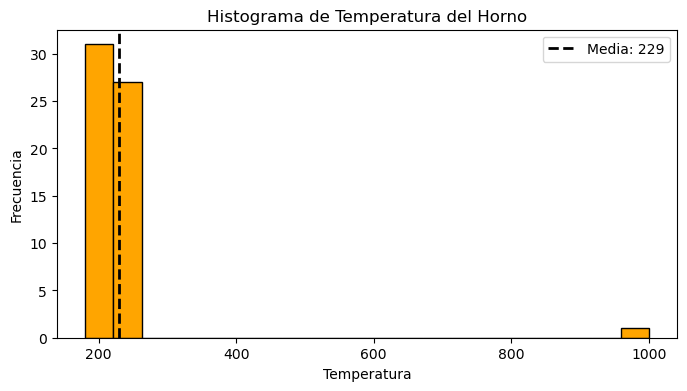

In [9]:
temperatura= df['temperatura_horno'].dropna()
estadisticas = temperatura.agg(['mean', 'median', 'std', 'min', 'max'])
print(estadisticas)
plt.figure(figsize=(8, 4))
plt.hist(temperatura, bins=20, color='orange', edgecolor='black')
plt.axvline(estadisticas['mean'], color='black', linestyle='dashed', linewidth=2, label=f"Media: {estadisticas['mean']:,.0f}")

plt.title('Histograma de Temperatura del Horno')
plt.xlabel('Temperatura')
plt.ylabel('Frecuencia')
plt.legend()

plt.show()

In [10]:
#¿La distribución de temperatura parece uniforme o concentrada? 
#la distribución está fuertemente concentrada. La  mayoría de los datos se agrupa en un solo bloque estrecho . No es uniforme en absoluto. Además, el gráfico revela visualmente un outlier extremo cerca de 1000
#Qué implica eso para la función de costo?
#Esto implica que para que la función de costo funcione correctamente y encuentre un mínimo global estable ya que el resto de los datos están muy bien concentrados, es estrictamente obligatorio eliminar ese outlier antes de optimizar.

In [11]:
#ejercicio 2

Costo calculado en 220°C: $1500.0
 El costo calculado coincide con el mínimo esperado.


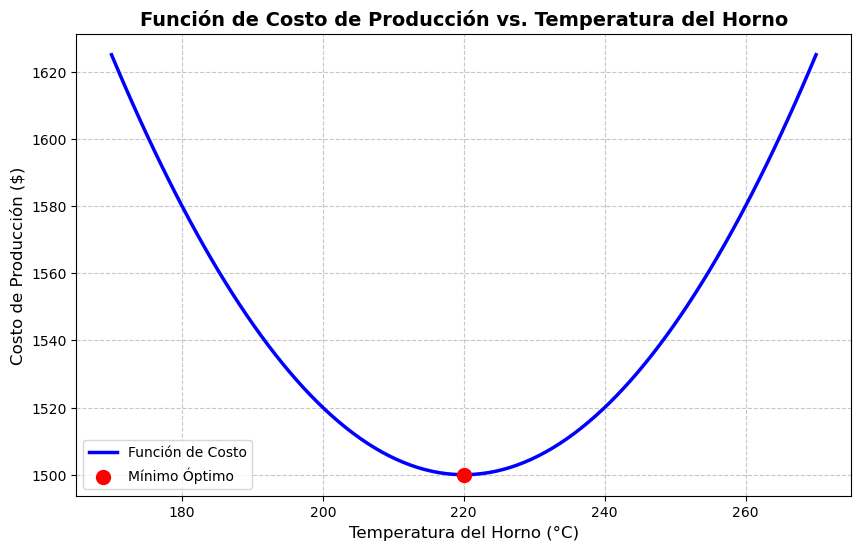

In [12]:
def costo_produccion(temperatura):
    """
    Modela el costo de producción por lote en función de la temperatura del horno.
    """
    T_optima = 220     
    costo_base = 1500   
    costo = 0.05 * (temperatura - T_optima)**2 + costo_base
    return costo
costo_calculado_min = costo_produccion(220)
print(f"Costo calculado en 220°C: ${costo_calculado_min}")
if round(costo_calculado_min, 2) == 1500.00:
    print(" El costo calculado coincide con el mínimo esperado.")
else:
    print(" El costo calculado no coincide con el esperado.")
temps_rango = np.linspace(170, 270, 100) 
costos_rango = costo_produccion(temps_rango) 
plt.figure(figsize=(10, 6)) 
plt.plot(temps_rango, costos_rango, color='blue', linewidth=2.5, label='Función de Costo')
plt.scatter(220, 1500, color='red', s=100, zorder=5, label='Mínimo Óptimo')
plt.title('Función de Costo de Producción vs. Temperatura del Horno', fontsize=14, fontweight='bold')
plt.xlabel('Temperatura del Horno (°C)', fontsize=12)
plt.ylabel('Costo de Producción ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

In [13]:
#¿es la función unimodal?
#sí es unimodal ya que una función es unimodal si tiene un único punto extremo (en este caso, un solo mínimo).
#Tiene sentido aplicar minimize_scalar directamente?
#sí,tiene  sentido ya que La función minimize_scalar está diseñada específicamente para encontrar el mínimo de funciones que dependen de una sola variable cuantitativa.

In [14]:
resultado_brent = minimize_scalar(costo_produccion, method='brent')
print(f"Temperatura óptima :{resultado_brent.x}")
print(f"Costo mínimo hallado :{resultado_brent.fun}")
print(f"Optimización exitosa :{resultado_brent.success}")
print(f"Número de iteraciones : {resultado_brent.nit}")

if resultado_brent.success:
    print("La optimización fue exitosa.")
else:
    print("La optimización fallo.")

Temperatura óptima :220.0000000000022
Costo mínimo hallado :1500.0
Optimización exitosa :True
Número de iteraciones : 4
La optimización fue exitosa.


In [15]:
# ¿la temperatura óptima hallada coincide con tu T_optima definida? 
#R:Sí, coincide de manera exacta.
#¿Por qué o por qué no?
#R:Porque la ecuación es una parábola perfecta cuyo punto mínimo matemático está diseñado para ocurrir exactamente en 220.

In [16]:
resultado_bounded = minimize_scalar(
    costo_produccion,
    bounds=(180, 250),
    method='bounded'
)
print(f"Temperatura óptima :{resultado_bounded.x}")
print(f"Costo mínimo hallado :{resultado_bounded.fun}")
print(f"Optimización exitosa :{resultado_bounded.success}")
print(f"Número de iteraciones:{resultado_bounded.nit}")

Temperatura óptima :220.00000000000006
Costo mínimo hallado :1500.0
Optimización exitosa :True
Número de iteraciones:6


In [17]:
#Compara resultado_brent.x con resultado_bounded.x. ¿Son iguales? ¿Cuál prefieres y por qué?
#Sí, ambos métodos encuentran exactamente el mismo valor óptimo, prefiero el bounded por que evita calculos que son fisica mente imposibles
#¿Cuál requiere más iteraciones?
#El método bounded requiere más iteraciones

In [18]:
comparacion = pd.DataFrame({
    'Metodo': ['brent', 'bounded'],
    'x_optimo': [resultado_brent.x, resultado_bounded.x],
    'costo_min': [resultado_brent.fun, resultado_bounded.fun],
    'iteraciones': [resultado_brent.nit, resultado_bounded.nit],
    'convergio': [resultado_brent.success, resultado_bounded.success]
})

print(comparacion.to_string(index=False))

 Metodo  x_optimo  costo_min  iteraciones  convergio
  brent     220.0     1500.0            4       True
bounded     220.0     1500.0            6       True


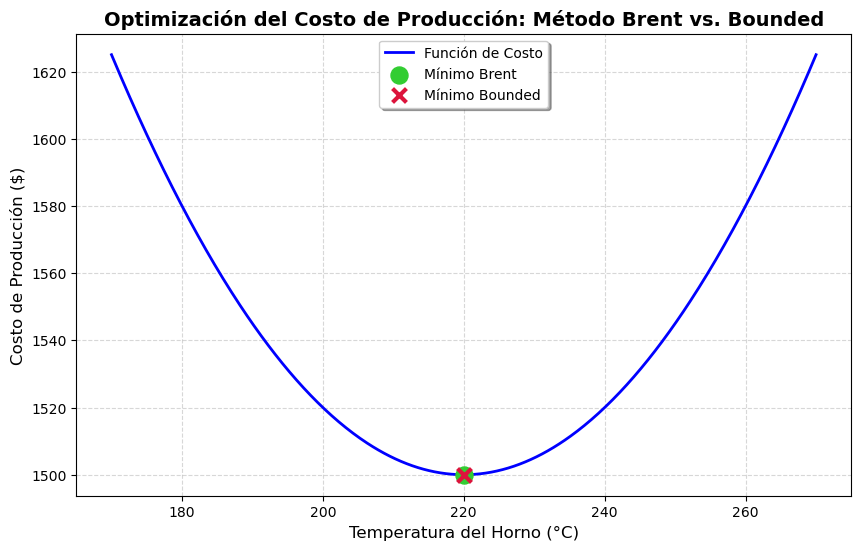

In [19]:

temperaturas = np.linspace(170, 270, 500)
costos = costo_produccion(temperaturas)
plt.figure(figsize=(10, 6))
plt.plot(temperaturas, costos, color='blue', linewidth=2, label='Función de Costo')
plt.scatter(resultado_brent.x, resultado_brent.fun, color='limegreen', s=150, zorder=4, label="Mínimo Brent")
plt.scatter(resultado_bounded.x, resultado_bounded.fun, color='crimson', marker='x', s=100, linewidths=3, zorder=5, label="Mínimo Bounded")
plt.title('Optimización del Costo de Producción: Método Brent vs. Bounded', fontsize=14, fontweight='bold')
plt.xlabel('Temperatura del Horno (°C)', fontsize=12)
plt.ylabel('Costo de Producción ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper center', frameon=True, shadow=True)
plt.show()

In [20]:
#1. ¿Qué ventaja práctica ofrece el argumento bounds en un contexto industrial real?
#En la industria real, los equipos operan bajo limitaciones físicas y de seguridad severas. La ventaja de usar bounds es que limita la búsqueda del algoritmo al rango seguro del horno (180 °C a 250 °C), impidiendo que el software evalúe temperaturas absurdas o peligrosas, Esto protege la integridad de los sistemas automáticos y evita cálculos innecesarios fuera de los límites operativos permitidos en la planta. 

#2. ¿Qué ocurriría si definimos una función de costo con múltiples mínimos locales? ¿minimize_scalar sería suficiente?
#Si la función tuviera múltiples mínimos locales, minimize_scalar no sería suficiente porque es un optimizador de carácter puramente local. Métodos como brent o bounded se quedarían inmediatamente atrapados en el primer bache matemático que encuentren cerca de su punto de partida, ignorando por completo el verdadero mínimo global del proceso.

#3. ¿Cómo cambiarías la función de costo si el efecto de la temperatura fuera asimétrico?
#Para modelar un escenario asimétrico (donde quedarse corto en temperatura afecte poco, pero pasarse del límite sea crítico por quemar el lote), modificaría la función utilizando la lógica condicional de np.where. Aplicaría una penalización cuadrática o lineal estándar cuando la temperatura sea menor al óptimo esperado, y activaría una penalización exponencial agresiva (o un término de potencia mucho mayor) en el momento en que la temperatura supere los 220 °C para castigar drásticamente el exceso de calor.